In [ ]:
library(dplyr)
library(ggplot2)
library(reshape2)

panel <- read.csv("../data/monthly_panel.csv")

print(colnames(panel))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




 [1] "package_name"              "year_month"               
 [3] "Vulnerability_count"       "Release_count"            
 [5] "Aggregate_score"           "Binary_Artifacts_score"   
 [7] "Code_Review_score"         "Contrib_score"            
 [9] "Dangerous_Workflow_score"  "DependUpTool_score"       
[11] "Fuzzing_score"             "License_score"            
[13] "Maintained_score"          "Pinned_Dependencies_score"
[15] "Security_Policy_score"     "Token_Permissions_score"  
[17] "loc"                       "downloads_7_day_total"    
[19] "dependents"                "version_age_days"         


In [5]:
check_cols <- c("Binary_Artifacts_score", "Code_Review_score", "Contrib_score", 
                 "Dangerous_Workflow_score", "DependUpTool_score", "Maintained_score",
                 "Pinned_Dependencies_score", "Security_Policy_score", "Token_Permissions_score")


df_demeaned <- panel %>%
  group_by(package_name) %>%
  mutate(across(all_of(check_cols), 
                ~ .x - mean(.x, na.rm = TRUE), 
                .names = "demean_{.col}")) %>%
  ungroup()

demean_cols <- paste0("demean_", check_cols)

co_implementation_matrix <- cor(df_demeaned[, demean_cols], 
                           use = "pairwise.complete.obs")

print(round(co_implementation_matrix, 2))

                                 demean_Binary_Artifacts_score
demean_Binary_Artifacts_score                             1.00
demean_Code_Review_score                                 -0.01
demean_Contrib_score                                      0.00
demean_Dangerous_Workflow_score                           0.01
demean_DependUpTool_score                                 0.00
demean_Maintained_score                                   0.00
demean_Pinned_Dependencies_score                          0.00
demean_Security_Policy_score                             -0.01
demean_Token_Permissions_score                           -0.01
                                 demean_Code_Review_score demean_Contrib_score
demean_Binary_Artifacts_score                       -0.01                 0.00
demean_Code_Review_score                             1.00                 0.05
demean_Contrib_score                                 0.05                 1.00
demean_Dangerous_Workflow_score                      0

In [7]:
head(df_demeaned)

package_name,year_month,Vulnerability_count,Release_count,Aggregate_score,Binary_Artifacts_score,Code_Review_score,Contrib_score,Dangerous_Workflow_score,DependUpTool_score,⋯,version_age_days,demean_Binary_Artifacts_score,demean_Code_Review_score,demean_Contrib_score,demean_Dangerous_Workflow_score,demean_DependUpTool_score,demean_Maintained_score,demean_Pinned_Dependencies_score,demean_Security_Policy_score,demean_Token_Permissions_score
<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0g,2024-04,120.3333,3,3.633333,7,0,3,10,0,⋯,0.00,-1.5,0,0,0,0,-0.3333333,0,0,0
0g,2024-05,121.3600,25,4.000000,10,0,3,10,0,⋯,13.76,1.5,0,0,0,0,0.3333333,0,0,0
0http,2024-04,0.0000,1,3.000000,10,0,0,10,0,⋯,1598.00,0.0,0,0,0,0,-2.9000000,0,0,0
0http,2025-01,0.0000,2,3.200000,10,0,0,10,0,⋯,1882.50,0.0,0,0,0,0,-1.4000000,0,0,0
0http,2025-02,0.0000,1,3.600000,10,0,0,10,0,⋯,1924.00,0.0,0,0,0,0,2.1000000,0,0,0
0http,2025-05,0.0000,1,3.500000,10,0,0,10,0,⋯,2013.00,0.0,0,0,0,0,0.1000000,0,0,0


## Visualization

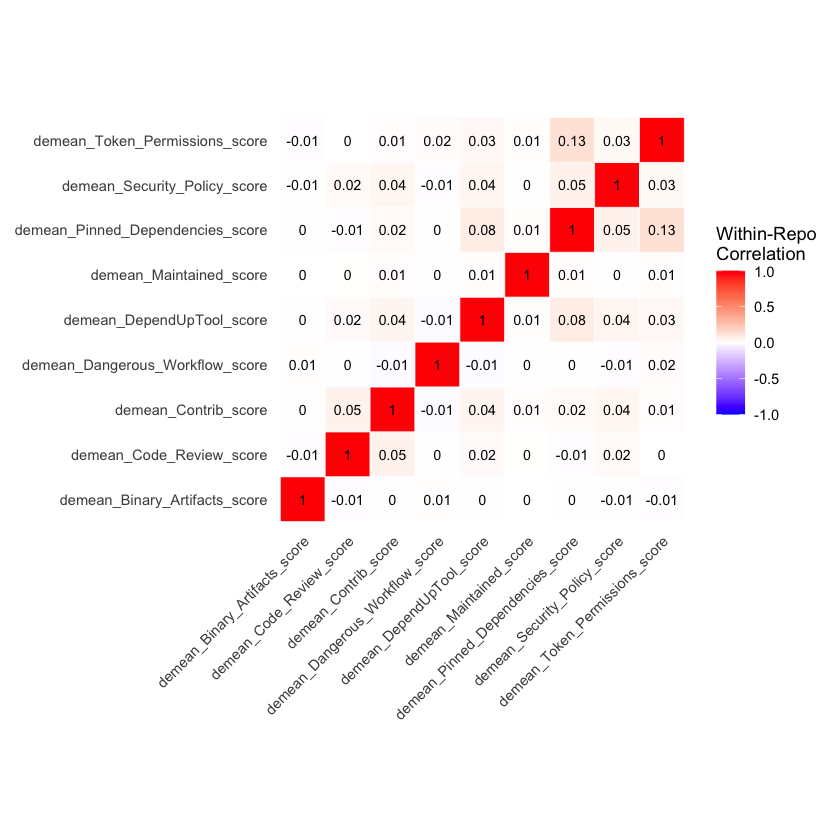

In [ ]:
# 1. Melt the matrix into a long format for ggplot
melted_matrix <- melt(co_implementation_matrix)

# 2. Plot the heatmap
ggplot(data = melted_matrix, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") + # Adds thin borders between tiles
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-1, 1), space = "Lab", 
                       name="Within-Repo\nCorrelation") +
  geom_text(aes(label = round(value, 2)), color = "black", size = 3) + # Overlays numbers
  theme_minimal() + 
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1), # Rotates labels
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        panel.grid.major = element_blank()) +
  coord_fixed() # Keeps the tiles perfectly square